In [ ]:
#!/g/data/xp65/public/apps/med_conda_scripts/analysis3-25.07.d/bin/python3
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import datetime
import xesmf as xe
import re

from dask.distributed import Client, wait
import os, sys
import psutil

sys.path.append('/home/548/cd3022/repos/Irradiance-comparisons/Irradiance-comparisons')
import logger
from read_datasets import read_dataset

LOG = logger.get_logger(__name__)
# qsub -I -q normal -P er8 -l walltime=3:00:00,ncpus=24,mem=120GB,jobfs=100MB,storage=gdata/xp65+gdata/er8+gdata/ob53+gdata/rt52+gdata/rv74+gdata/su28

# Set up Dask

In [2]:
# client = setup_dask_client(workload_type="cpu")
client = Client(
    n_workers=48,
    threads_per_worker=1
)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 48
Total threads: 48,Total memory: 95.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46009,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36429,Total threads: 1
Dashboard: /proxy/38523/status,Memory: 1.98 GiB
Nanny: tcp://127.0.0.1:44735,


# Prepare Data

In [ ]:
# ds_list = []
# for year in range(2016, 2025):
#     file_path = Path(f"/scratch/er8/cd3022/Irradiance-comparisons/himawari_barrar2_diffct_{year}.zarr")
#     ds_year = xr.open_zarr(file_path, consolidated=False)
#     ds_list.append(ds_year)
# ds = xr.concat(ds_list, dim='time')

# OR

file_path = Path(f"/scratch/er8/cd3022/Irradiance-comparisons/himawari_barrar2_diffct.zarr")
ds = xr.open_zarr(file_path)

In [ ]:
# BARRA Cloud Types
BARRA = Path('/g/data/ob53/BARRA2/output/reanalysis/')
BARRA_R2 = BARRA / "AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1"
BARRA_R2_DIR = BARRA_R2 / "1hr"

vars_to_open = [
    'clh',
    'clm',
    'cll'
]
def _preprocess(ds):
    return ds.sel(lat=slice(-44.5, -10), lon=slice(112, 156.26), time=slice('2016', '2024'))

ds_vars = []
for var in vars_to_open:

    files = sorted([f for f in BARRA_R2_DIR.glob(f'{var}/latest/*1hr_20*.nc')])
    ds_b = xr.open_mfdataset(files,
                        chunks={'time':24, 'lat':157, 'lon':31},
                        concat_dim='time',
                        combine='nested',
                        data_vars='minimal',
                        coords='minimal',
                        compat='override',
                        parallel=True,
                        preprocess=_preprocess
                        )
    ds_vars.append(ds_b)
barra_r2 = xr.merge(ds_vars)
LOG.info('BARRA-R2 opened')

# assign cloud_type based on fractions at different levels
barra_ct = (
    (barra_r2.cll >= 50).astype(int) * 1 +
    (barra_r2.clm >= 50).astype(int) * 2 +
    (barra_r2.clh >= 50).astype(int) * 4
)
barra_ct.attrs['description'] = '0: all < 50%; 1: low >= 50; 2: mid >= 50%; 3: low and mid >= 50%; 4: high >= 50%; 5: low and high >= 50%; 6: mid and high >= 50%; 7: all >= 50%'

# Plot Time Step of All Cloud Types
From Sam Green's tutorial notebook code

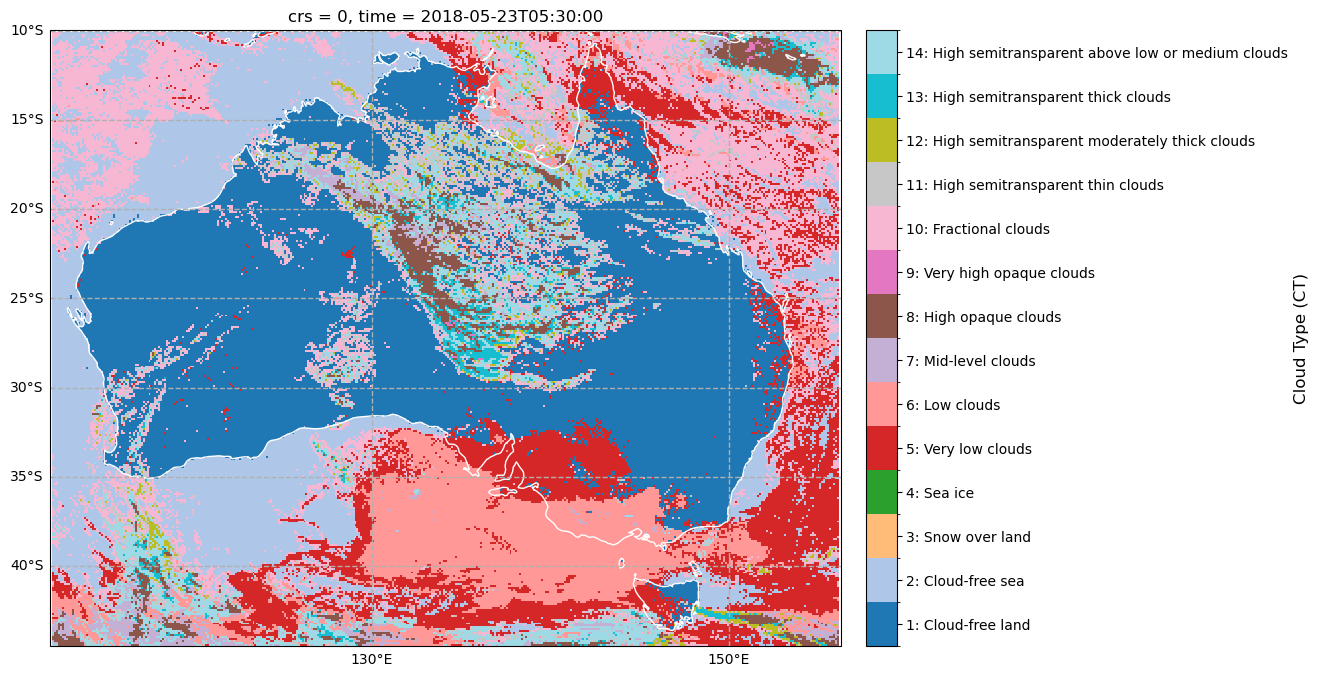

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import matplotlib.cm as cm
import cartopy.crs as ccrs
import cartopy.feature as cft
import cmocean as cmo
import matplotlib as mpl
import matplotlib.ticker as mticker

import re

comment = '1:  Cloud-free land; 2:  Cloud-free sea; 3:  Snow over land;  4:  Sea ice; 5:  Very low clouds; 6:  Low clouds; 7:  Mid-level clouds;  8:  High opaque clouds; 9:  Very high opaque clouds;  10:  Fractional clouds; 11:  High semitransparent thin clouds;  12:  High semitransparent moderately thick clouds;  13:  High semitransparent thick clouds;  14:  High semitransparent above low or medium clouds;  15:  High semitransparent above snow/ice'

# Use regex to extract values and labels
matches = re.findall(r'(\d+):\s+([^;]+)', comment)
category_dict = {int(num): desc.strip() for num, desc in matches}

fig = plt.figure(figsize=(16, 8))

ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=130))
ax.coastlines(resolution="50m", color='white')

# Define the values and corresponding colors from tab20
values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]  # Adjust based on your dataset
# Set the min and max colors from tab20
min_color = mpl.colormaps['tab20'](0 / 20)
max_color = mpl.colormaps['tab20'](19 / 20)  # Last color of tab20

# Generate intermediate colors by linearly spacing them within tab20
num_classes = len(values)
colors = [mpl.colormaps['tab20'](i / (num_classes - 1)) for i in range(num_classes)]

# Ensure min/max colors are set explicitly
colors[0] = min_color
colors[-1] = max_color

# Create discrete colormap
cmap = mcolors.ListedColormap(colors)
# Define boundaries for normalization (each value gets its own bin)
boundaries = np.arange(min(values) - 0.5, max(values) + 1.5, 1)  # Adjusted for correct binning
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

img = ds.sel(time=f'{year}-05-23T05:30:00.000000000').ct.plot(ax=ax, x="lon", y="lat", transform=ccrs.PlateCarree(), cmap=cmap, norm=norm, add_colorbar=False)

# Add a discrete colorbar
cbar = fig.colorbar(img, ax=ax, orientation="vertical", fraction=0.03, pad=0.02)
cbar.set_label("Cloud Type (CT)", fontsize=12)
cbar.set_ticks(values)  # Ensure ticks match category values
cbar.set_ticklabels([f"{k}: {v}" for k, v in sorted(category_dict.items())[:14]])  # Custom labels

# Add gridlines with labels
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=1.0)
gl.top_labels = False  # Disable top labels
gl.right_labels = False  # Disable right labels

# Increase the number of ticks on the x-axis
gl.xlocator = mticker.FixedLocator(np.arange(70, 190, 20))  # Adjust step size as needed

# CT Errors

## Loop over CTs and calculate each of their errors

In [ ]:
cloud_aggs = {
    'clear_sky':[1,2,3,4],
    'low':[5,6],
    'med':[7],
    'high_opaque':[8,9],
    'fractional': [10],
    'high_semitransparent': [11,12,13,14]
}

In [ ]:
# RMSE
total = xr.where(ds.ghi_diff.isnull(), 0, 1).sum().compute().item()

rmse = {}
ct_counts = {}
# for ct in cloud_aggs:
for ct in range(1,15):
    # ct_codes = cloud_aggs[ct]
    # ct_diffs = xr.where(ds.ct.isin(ct_codes), ds.ghi_diff, np.nan)
    ct_diffs = xr.where(ds.ct == ct, ds.ghi_diff, np.nan)
    ct_errors = np.sqrt((ct_diffs**2).mean(dim=['lat', 'lon'], skipna=True)).compute().data
    ct_errors = ct_errors[~np.isnan(ct_errors)]
    rmse[ct] = ct_errors

    # ct_counts[ct] = xr.where(
    #     ds.ct.isin(ct_codes) & ~(ds.ghi_diff.isnull()), 1, 0
    # ).sum().compute().data / total
    ct_counts[ct] = xr.where(
        (ds.ct == ct) & (ds.ghi_diff.notnull()), 1, 0
    ).sum().compute().item() / total

In [ ]:
# MBE

total = xr.where(ds.ghi_diff.isnull(), 0, 1).sum().compute().item()

mbe = {}
# for ct in cloud_aggs:
for ct in range(1,15):
    if ct in (3,4):
        continue
    # ct_codes = cloud_aggs[ct]
    # ct_diffs = xr.where(ds.ct.isin(ct_codes), ds.ghi_diff, np.nan)
    ct_diffs = xr.where(ds.ct == ct, ds.ghi_diff, np.nan)
    ct_mbe = ct_diffs.mean(dim=['lat', 'lon'], skipna=True).compute().data
    ct_mbe = ct_mbe[~np.isnan(ct_mbe)]
    mbe[ct] = ct_mbe

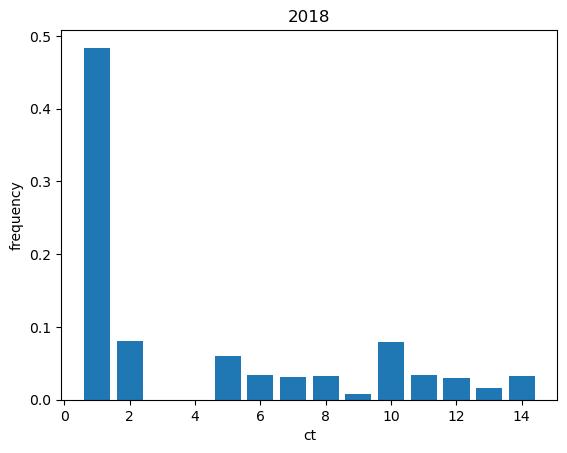

In [11]:
plt.bar(ct_counts.keys(), ct_counts.values())
plt.title(year)
plt.xlabel('ct')
plt.ylabel('frequency')
plt.savefig(f'/home/548/cd3022/figures/Irradiance_comparisons/{year}_ct_histogram.png')

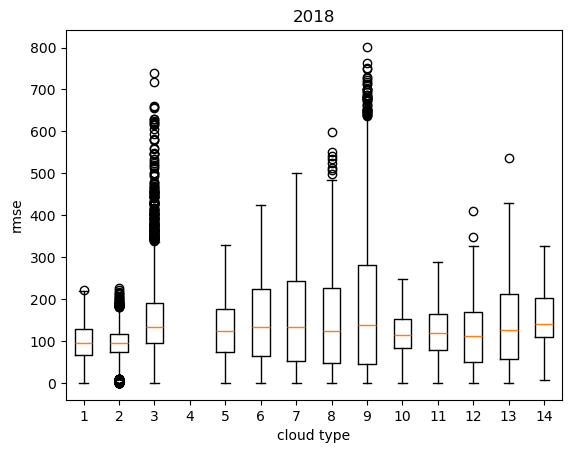

In [12]:
plt.boxplot(
    rmse.values(),
    tick_labels=rmse.keys(),
)
plt.xlabel('cloud type')
plt.ylabel('rmse')
plt.title(year)
plt.savefig(f'/home/548/cd3022/figures/Irradiance_comparisons/{year}_ct_error_boxplot.png')

In [ ]:
plt.boxplot(
    mbe.values(),
    tick_labels=mbe.keys(),
)
plt.xlabel('cloud type')
plt.ylabel('mbe')
plt.title(year)
plt.axhline(0)
plt.savefig(f'/home/548/cd3022/figures/Irradiance_comparisons/{year}_ct_mbe_boxplot.png')
plt.close()

## Himawari vs BARRA Cloud Matrices

In [ ]:
# Cloud type frequency matrix
df_list = []
for month in range(1, 13):  # January to December
    month_str = f'{month:02d}'
    ds_month = ds.sel(time=f'2018-{month_str}')
    barra_ct_month = barra_ct.sel(time=f'2018-{month_str}')
    barra_ct_month = barra_ct_month.sel(time=ds_month.time, method='nearest')

    cloud_aggs = {
        'clear_sky': [1,2,3,4],
        'low': [5,6],
        'med': [7],
        'high_opaque': [8,9],
        'fractional': [10],
        'high_semitransparent': [11,12,13,14]
    }

    for i, agg in enumerate(cloud_aggs):
        ct_codes = cloud_aggs[agg]
        ds_month = xr.where(ds_month.isin(ct_codes), i, ds_month)

    h_categories = {int(num): desc for num, desc in enumerate(cloud_aggs.keys())}
    b_matches = re.findall(r'(\d+):\s+([^;]+)', barra_ct.attrs['description'])
    b_categories = {int(num): desc.strip() for num, desc in b_matches}

    h_ct = ds_month.ct.compute().values
    b_ct = barra_ct_month.compute().values

    freq = pd.crosstab(
        index=h_ct.ravel(),
        columns=b_ct.ravel(),
        normalize='all'  # monthly relative frequencies
    )
    freq = freq.reindex(index=range(len(h_categories)), columns=range(len(b_categories)), fill_value=0)
    df_list.append(freq)
    print(f'Done: {month}')

# combine months into a single year of data
weights = []
for freq_df, month in zip(df_list, range(1, 13)):
    ds_month = ds.sel(time=f'2018-{month:02d}')
    n_points = ds_month.time.size
    weights.append(n_points)

# normalize weights
weights = np.array(weights) / np.sum(weights)

# weighted average
freq_year = sum(w * df for w, df in zip(weights, df_list))



plt.figure(figsize=(16, 12))
sns.heatmap(
    freq_year,                     # your crosstab DataFrame
    cmap='viridis',           # or 'coolwarm', 'YlGnBu', etc.
    annot=True,               # show the frequency values
    fmt=".4f",                # format numbers (2 decimal places)
    cbar_kws={'label': 'Frequency'},
    # vmax=0.02
)


plt.xticks(list(b_categories.keys()), list(b_categories.values()), rotation=30)
plt.yticks(list(h_categories.keys()), list(h_categories.values()))

plt.xlabel("Barra cloud type", fontsize=14)
plt.ylabel("Himawari cloud type", fontsize=14)
plt.title("Cloud type frequency 2018", fontsize=16)
plt.tight_layout()
plt.savefig('/home/548/cd3022/figures/Irradiance_comparisons/ct_matrix_freq.png')
plt.close()

In [ ]:
# Cloud type MBE matrix
df_list = []
for month in range(1, 13):
    month_str = f'{month:02d}'
    him_ct_month = ds.ct.sel(time=f'2018-{month_str}')
    diff_month = ds.ghi_diff.sel(time=him_ct_month.time, method='nearest')
    barra_ct_month = barra_ct.sel(time=him_ct_month.time, method='nearest')

    cloud_aggs = {
        'clear_sky':[1,2,3,4],                  # 0
        'low':[5,6],                            # 1
        'med':[7],                              # 2
        'high_opaque':[8,9],                    # 3
        'fractional': [10],                     # 4
        'high_semitransparent': [11,12,13,14]   # 5
    }

    for i, agg in enumerate(cloud_aggs):
        ct_codes = cloud_aggs[agg]
        him_ct_month = xr.where(him_ct_month.isin(ct_codes), i, him_ct_month)

    h_categories = {int(num): desc for num, desc in enumerate(cloud_aggs.keys())}

    b_matches = re.findall(r'(\d+):\s+([^;]+)', barra_ct.attrs['description'])
    b_categories = {int(num): desc.strip() for num, desc in b_matches}

    # him_ct_month, barra_ct_month, diff_month = xr.align(him_ct_month, barra_ct_month, diff_month, join="inner")

    h_ct = him_ct_month.values.ravel()
    b_ct = barra_ct_month.values.ravel()
    diff_vals = diff_month.values.ravel()

    df = pd.DataFrame({
        "h_ct": h_ct,
        "b_ct": b_ct,
        "diff": diff_vals
    }).dropna(subset=["h_ct", "b_ct", "diff"])

    # Mean bias error (signed mean)
    mbe = df.groupby(["h_ct", "b_ct"])["diff"].mean().unstack(fill_value=np.nan)

    # Reindex to fill all possible categories
    mbe = mbe.reindex(
        index=range(len(h_categories)),
        columns=range(len(b_categories)),
        fill_value=np.nan
    )
    df_list.append(mbe)
    print(f'Done {month_str}')

# combine months into a single year of data
weights = []
for mbe_df, month in zip(df_list, range(1, 13)):
    ds_month = ds.sel(time=f'2018-{month:02d}')
    n_points = ds_month.time.size
    weights.append(n_points)

# normalize weights
weights = np.array(weights) / np.sum(weights)

# weighted average
mbe_year = sum(w * df for w, df in zip(weights, df_list))

plt.figure(figsize=(14, 10))
ax = sns.heatmap(
    mbe_year,
    cmap="RdBu_r",          # Red = positive bias, Blue = negative bias
    center=0,               # zero-centered colormap
    annot=True,
    fmt=".1f",
    cbar_kws={"label": "Mean Bias Error (W/m²)"},
    square=True
)

# Center ticks on boxes
ax.set_xticks(np.arange(mbe.shape[1]) + 0.5)
ax.set_yticks(np.arange(mbe.shape[0]) + 0.5)

ax.set_xticklabels(list(b_categories.values()), rotation=30, ha='right')
ax.set_yticklabels(list(h_categories.values()))

plt.xlabel("BARRA cloud type")
plt.ylabel("Himawari cloud type")
plt.title("GHI MBE by Cloud Type 2018")
plt.tight_layout()
plt.savefig('/home/548/cd3022/figures/Irradiance_comparisons/ct_matrix_mbe.png')
plt.close()

In [ ]:
combined_freq_mbe = freq_year * mbe_year

plt.figure(figsize=(14, 10))
ax = sns.heatmap(
    combined_freq_mbe,
    cmap="RdBu_r",          # Red = positive bias, Blue = negative bias
    center=0,               # zero-centered colormap
    annot=True,
    fmt=".1f",
    cbar_kws={"label": "Freq * MBE"},
    square=True
)

# Center ticks on boxes
ax.set_xticks(np.arange(mbe.shape[1]) + 0.5)
ax.set_yticks(np.arange(mbe.shape[0]) + 0.5)

ax.set_xticklabels(list(b_categories.values()), rotation=30, ha='right')
ax.set_yticklabels(list(h_categories.values()))

plt.xlabel("BARRA cloud type")
plt.ylabel("Himawari cloud type")
plt.title("Combined Freq/MBE 2018")
plt.tight_layout()
plt.savefig('/home/548/cd3022/figures/Irradiance_comparisons/ct_matrix_mbefreq.png')
plt.close()